W Query dynamic range failed. Ret code: RKNN_ERR_MODEL_INVALID. (If it is a static shape RKNN model, please ignore the above warning message.)


YOLO : --> Load YOLO26 model
done
YOLO : --> Init runtime environment YOLO26
I RKNN: [10:25:15.483] RKNN Runtime Information, librknnrt version: 2.4.0 (b458df3b4a@2026-01-17T10:53:35)
I RKNN: [10:25:15.484] RKNN Driver Information, version: 0.9.8
I RKNN: [10:25:15.484] RKNN Model Information, version: 6, toolkit version: 2.3.2(compiler version: 2.3.2 (@2025-04-03T08:26:16)), target: RKNPU v2, target platform: rk3588, framework name: ONNX, framework layout: NCHW, model inference type: static_shape
W RKNN: [10:25:15.542] query RKNN_QUERY_INPUT_DYNAMIC_RANGE error, rknn model is static shape type, please export rknn with dynamic_shapes
done
(640, 640)
YOLO : Inference time: 95.92509269714355 ms


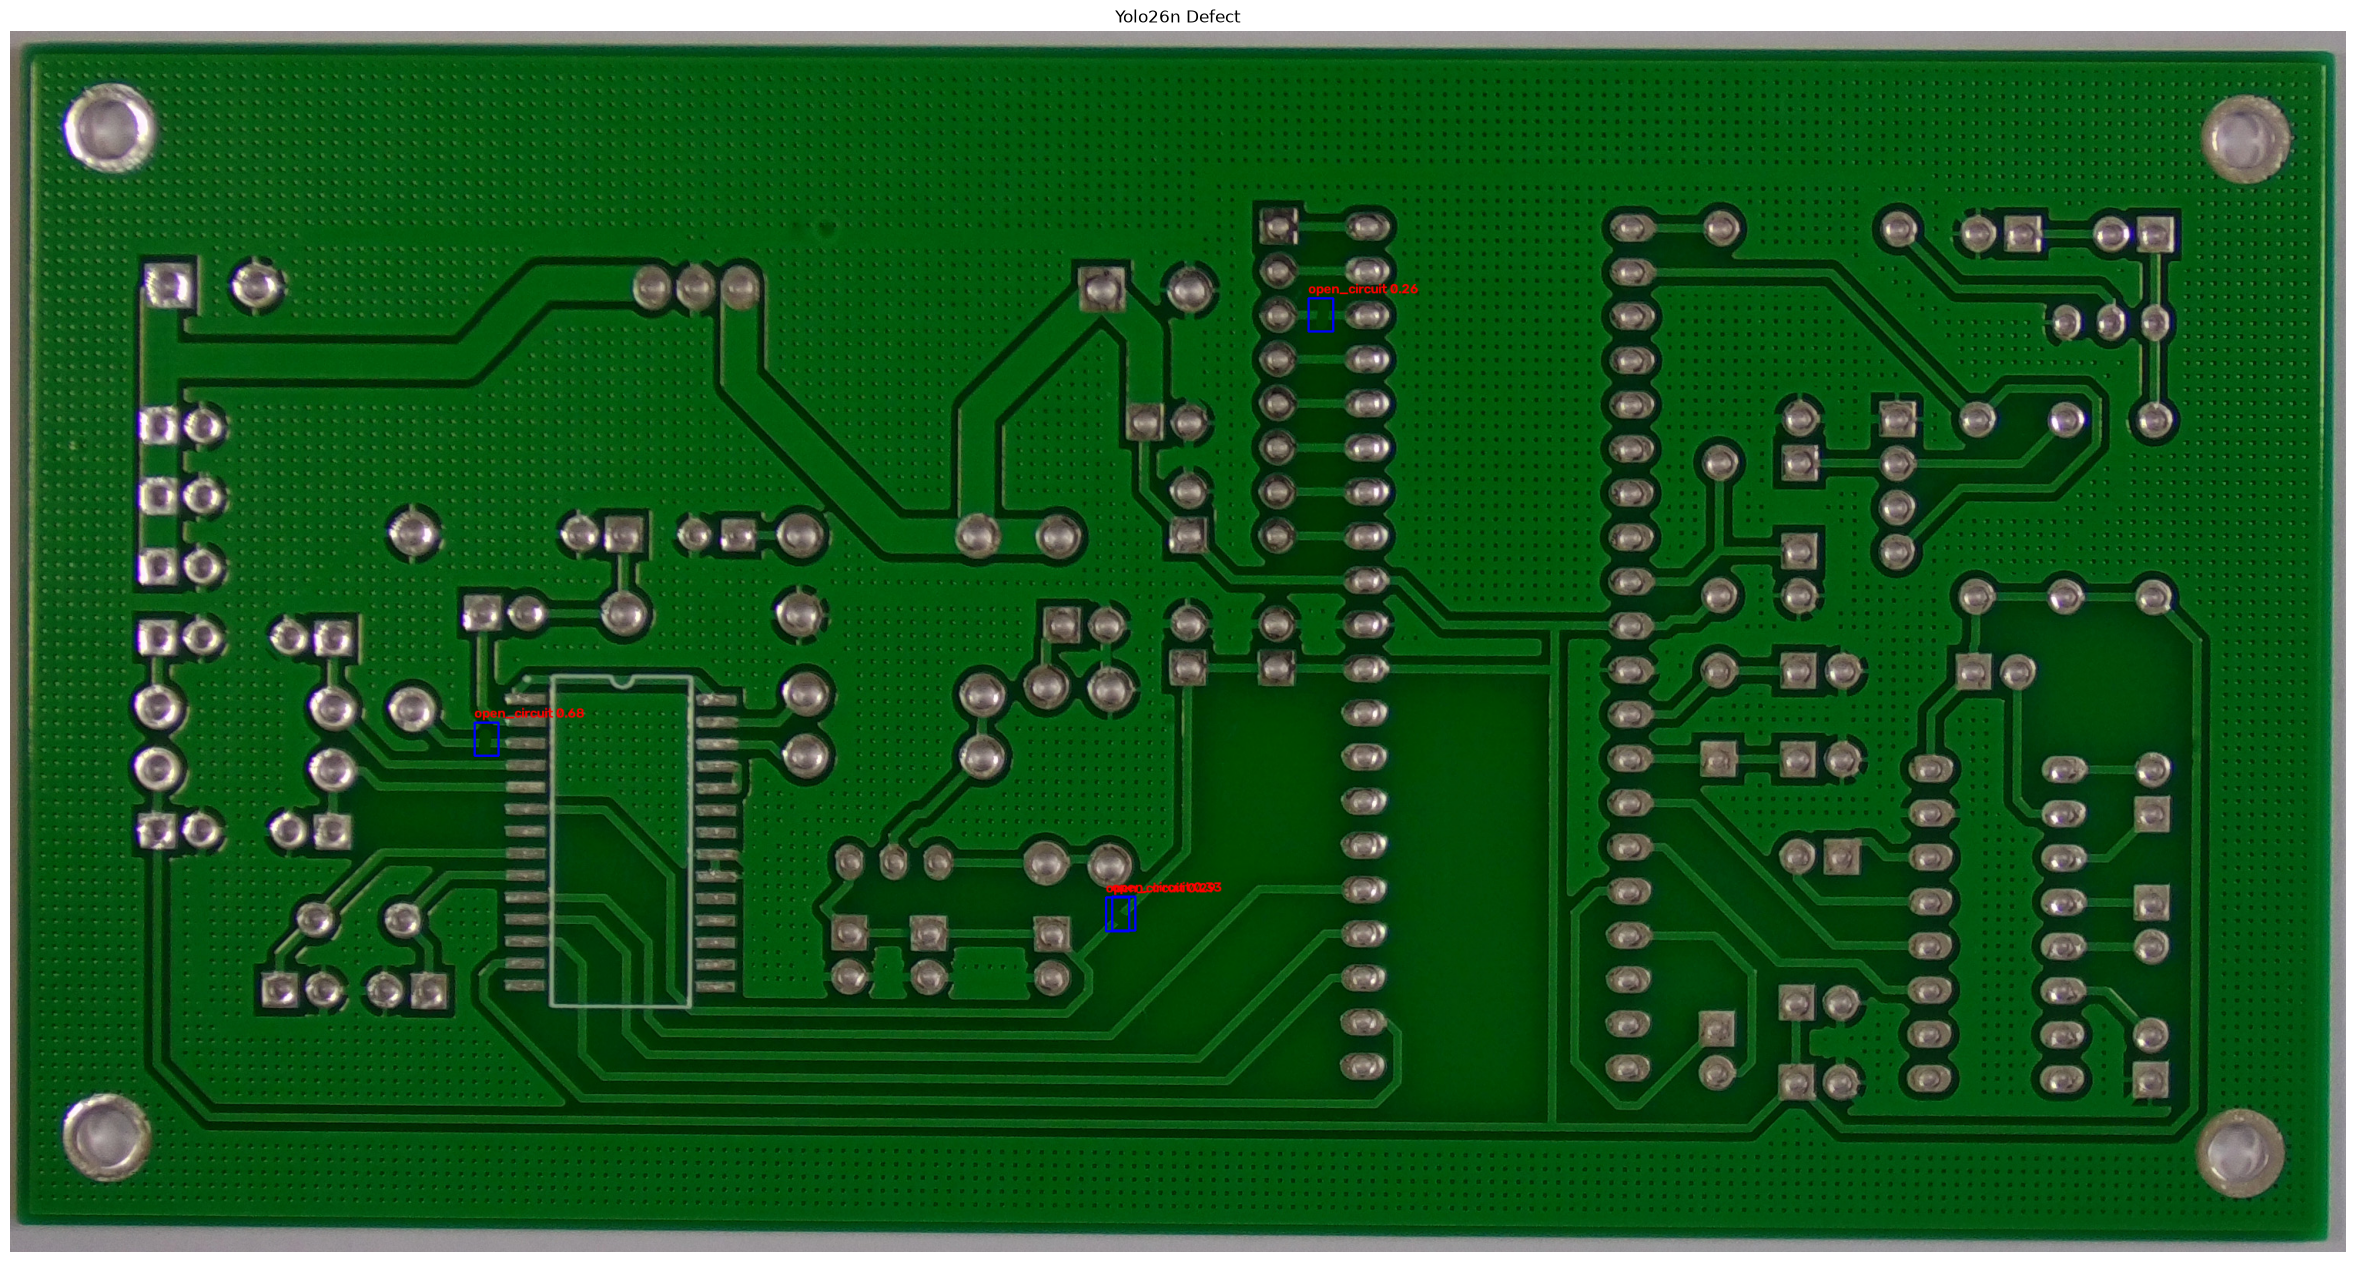

YOLO : RKNN Detect Release!!


In [3]:
import numpy as np
import cv2
from copy import copy
import platform
from yolo26detect import *
from utils import *
from rknnlite.api import RKNNLite
import time 

# Not Working PCB

#RK3588_RKNN_MODEL = './models/detect/yolo26n-LicensePlate-RK3588_320.rknn'
#RK3588_RKNN_MODEL = './models/detect/yolo26n-RK3588_320.rknn'
RK3588_RKNN_MODEL = './models/detect/pcb-defect-RK3588_640.rknn'
#IMG_PATH = './images/LicensePlate.jpg'
#IMG_PATH = './images/bus.jpg'
#IMG_PATH = './images/PCB/Missing_hole/01_missing_hole_01.jpg'
#IMG_PATH = './images/PCB/Mouse_bite/01_mouse_bite_02.jpg'
IMG_PATH = './images/PCB/Open_circuit/01_open_circuit_03.jpg'
OBJ_THRESH = 0.25
IMG_SIZE = "640"
VIEW = True

if __name__ == "__main__":
        yolo = Yolo26Detect(RK3588_RKNN_MODEL, input_size = IMG_SIZE, OBJ_THRESH = OBJ_THRESH,DATASET=PCB)
        print( detect_imgsz_from_path(RK3588_RKNN_MODEL))
        start_time = time.time()
        objects = yolo(IMG_PATH)
        if VIEW:
                yolo.draw(objects)
                plt_img_show(yolo.img_result, "Yolo26n Defect", percent=100)
                #cv2.imshow("post process result", yolo.img_result)
                #cv2.waitKey(0)
                #cv2.destroyAllWindows()
                
        yolo.release()

W Query dynamic range failed. Ret code: RKNN_ERR_MODEL_INVALID. (If it is a static shape RKNN model, please ignore the above warning message.)


YOLO : --> Load YOLO26 model
done
YOLO : --> Init runtime environment YOLO26
I RKNN: [16:09:48.825] RKNN Runtime Information, librknnrt version: 2.4.0 (b458df3b4a@2026-01-17T10:53:35)
I RKNN: [16:09:48.825] RKNN Driver Information, version: 0.9.8
I RKNN: [16:09:48.826] RKNN Model Information, version: 6, toolkit version: 2.3.2(compiler version: 2.3.2 (@2025-04-03T08:26:16)), target: RKNPU v2, target platform: rk3588, framework name: ONNX, framework layout: NCHW, model inference type: static_shape
W RKNN: [16:09:48.834] query RKNN_QUERY_INPUT_DYNAMIC_RANGE error, rknn model is static shape type, please export rknn with dynamic_shapes
done
YOLO : Inference time: 9.025335311889648 ms
19오7777


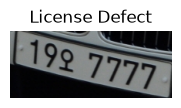

YOLO : RKNN Detect Release!!


In [3]:
import numpy as np
import cv2
from copy import copy
import platform
import math
from yolo26detect import *
from utils import *
from alpr_kor import *
from rknnlite.api import RKNNLite
import time 

# Not Working PCB

RK3588_RKNN_MODEL = './models/detect/yolo26n-LicensePlate-RK3588_320_i8.rknn'
IMG_PATH = './images/LicensePlate.jpg'
OBJ_THRESH = 0.25
IMG_SIZE = 320
VIEW = True

if __name__ == "__main__":
        yolo = Yolo26Detect(RK3588_RKNN_MODEL,input_size = IMG_SIZE, OBJ_THRESH = OBJ_THRESH,DATASET=LICENSE)
        alpr = TFliteDemo('alpr_kor.tflite')
        start_time = time.time()
        objects = yolo(IMG_PATH)
        #yolo.draw(objects)
        for obj in objects:
            #print(f"Class: {obj['class']}, Score: {obj['score']:.2f}, Box: {obj['box']}")
            left, top, right, bottom = obj['box']
            plate_image = yolo.img_org[top:bottom,left:right].copy()
            just_image = just( plate_image )
            #start_time = time.time()
            new_label, conf = alpr.run(just_image)
            print( new_label )
            #cv2.imshow("post process result", plate_image)
            #cv2.waitKey(0)
            #cv2.destroyAllWindows()
        if VIEW:
                #yolo.draw(objects)
                #yolo.draw()
                #cv2.imwrite('result.jpg', yolo.img_result)
                #print('Save results to result.jpg!')
                #cv2.imshow("post process result", yolo.img_result)
                #cv2.waitKey(0)

                #show_rgb_image(img_org, 'post process result')

                #cv2.destroyAllWindows()
                plt_img_show(plate_image, "License Defect", percent=100)
        yolo.release()